# Invoking 2 Prompt JSON Files in Parallel — LangGraph

## The problem
A user reports an issue that touches **two domains at once** — email delivery AND CRM sync.
Running them sequentially wastes time. Running them in parallel halves the wait.

## The solution — parallel fan-out
```
single user input
  → fan_out          (load both JSON files)
  → [run_email_prompt]  ──┐  ← both run simultaneously
  → [run_crm_prompt]    ──┤  ← asyncio.gather()
  → merge_responses      ←┘  (combine both outputs)
  → combined report
```

## Two prompt files used
```
prompts_dual/
  email_prompt.json  ← SMTP, bounce, DKIM, deliverability expert
  crm_prompt.json    ← HubSpot/Salesforce sync, webhook, dedup expert
```

In [1]:
from typing import TypedDict, Optional
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from langchain_core.messages import SystemMessage, HumanMessage, AIMessage
from IPython.display import Image, display
from dotenv import load_dotenv
import json, os, asyncio

load_dotenv()
os.environ["OPENAI_API_KEY"] = os.getenv("OPENAI_API_KEY")

PROMPTS_DIR = "prompts_dual"

# Fix for Jupyter: patch the running event loop so asyncio works inside it
try:
    import nest_asyncio
except ImportError:
    import subprocess, sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "nest_asyncio", "-q"])
    import nest_asyncio
nest_asyncio.apply()
print("nest_asyncio applied — asyncio.gather() will work inside Jupyter")

nest_asyncio applied — asyncio.gather() will work inside Jupyter


In [2]:
# ── State ─────────────────────────────────────────────────
# Holds inputs and both prompt results side by side.

class DualState(TypedDict):
    # Inputs
    customer_name: str
    crm_platform:  str
    user_message:  str

    # Loaded prompt configs (set by fan_out)
    email_config:  Optional[dict]
    crm_config:    Optional[dict]

    # Individual LLM results (set by parallel run nodes)
    email_response: Optional[dict]
    crm_response:   Optional[dict]

    # Final merged output
    combined_report: Optional[dict]

In [3]:
# ── Helper: load one JSON file ────────────────────────────
def load_json(filename: str) -> dict:
    path = os.path.join(PROMPTS_DIR, filename)
    with open(path) as f:
        return json.load(f)


# ── Helper: call LLM from a prompt config ─────────────────
async def call_prompt_async(config: dict, user_vars: dict) -> dict:
    """Async LLM call — runs both prompts simultaneously."""
    llm = ChatOpenAI(
        model       = config["model"]["name"],
        temperature = config["model"]["temperature"],
        max_tokens  = config["model"]["max_tokens"],
    )

    # Build messages: system + few-shot + rendered user template
    messages = [SystemMessage(content=config["prompt"]["system"])]

    for ex in config.get("few_shot_examples", []):
        if ex["role"] == "user":
            messages.append(HumanMessage(content=ex["content"]))
        elif ex["role"] == "assistant":
            messages.append(AIMessage(content=ex["content"]))

    template = config["prompt"]["user_template"]
    rendered = template.format(**user_vars)
    messages.append(HumanMessage(content=rendered))

    response = await llm.ainvoke(messages)

    # Parse JSON output
    try:
        clean = response.content.strip().lstrip("```json").rstrip("```").strip()
        return json.loads(clean)
    except json.JSONDecodeError:
        return {"domain": config["metadata"]["domain"],
                "raw": response.content.strip()}

fan_out (Load both prompt configurations)

Purpose

Load the two prompt JSON files (email and CRM) from disk. This is the only sequential step before parallel execution.

How it works

Calls load_json("email_prompt.json") and load_json("crm_prompt.json").

Stores the loaded configurations in email_config and crm_config respectively.

Prints which versions were loaded (e.g., email_specialist v1.0.0).

Output

State with both prompt configurations populated.



In [4]:
# ── Node 1: fan_out ───────────────────────────────────────
# Loads BOTH JSON files from disk.
# This is the only sequential step — everything after runs in parallel.

def fan_out(state: DualState) -> DualState:
    print("[fan_out] Loading both prompt JSON files...")

    email_config = load_json("email_prompt.json")
    crm_config   = load_json("crm_prompt.json")

    print(f"  Loaded: {email_config['metadata']['name']} v{email_config['metadata']['version']}")
    print(f"  Loaded: {crm_config['metadata']['name']}   v{crm_config['metadata']['version']}")

    return {**state, "email_config": email_config, "crm_config": crm_config}

run_both_prompts_parallel (Parallel LLM invocation)

Purpose

Execute both domain‑specific prompts simultaneously using asyncio.gather(), so the total time equals the slower of the two LLM calls, not the sum.

How it works

Prepares two separate sets of user_vars:

For email: customer_name and user_message

For CRM: customer_name, crm_platform, and user_message

Defines an async function run_parallel() that creates two tasks:

email_task = call_prompt_async(email_config, email_vars)

crm_task = call_prompt_async(crm_config, crm_vars)

Uses asyncio.gather(email_task, crm_task) to run both concurrently.

Runs the async function inside the existing event loop (using loop.run_until_complete), with nest_asyncio applied to work inside Jupyter.

Stores the results in email_response and crm_response.

Output

State with both LLM responses (parsed JSON objects).

Helper: call_prompt_async

Creates a ChatOpenAI instance using model settings from the prompt config (name, temperature, max_tokens).

Builds messages: system prompt → few‑shot examples → rendered user template (with user_vars).

Calls llm.ainvoke(messages) asynchronously.

Strips markdown fences and parses JSON. Returns the parsed dict.



In [5]:
# ── Node 2: run_both_prompts_parallel ─────────────────────
# The KEY node — runs BOTH LLM calls at the same time using asyncio.
# asyncio.gather() fires both API requests simultaneously.
# Total time = max(email_time, crm_time)  instead of  email_time + crm_time

def run_both_prompts_parallel(state: DualState) -> DualState:
    print("\n[run_both] Firing both LLM calls in parallel...")

    user_vars_email = {
        "customer_name": state["customer_name"],
        "user_message":  state["user_message"],
    }
    user_vars_crm = {
        "customer_name": state["customer_name"],
        "crm_platform":  state["crm_platform"],
        "user_message":  state["user_message"],
    }

    async def run_parallel():
        # Both tasks start at the same moment
        email_task = call_prompt_async(state["email_config"], user_vars_email)
        crm_task   = call_prompt_async(state["crm_config"],   user_vars_crm)
        return await asyncio.gather(email_task, crm_task)

    # Jupyter-safe: use the existing event loop instead of asyncio.run()
    loop = asyncio.get_event_loop()
    email_result, crm_result = loop.run_until_complete(run_parallel())

    print(f"  Email domain result: severity={email_result.get('severity')}")
    print(f"  CRM domain result:   severity={crm_result.get('severity')}")

    return {**state, "email_response": email_result, "crm_response": crm_result}

merge_responses (Combine and unify outputs)

Purpose

Take the two independent responses and create a single, coherent report that covers both domains, determines overall severity, and recommends an action order.

How it works

Extracts email_response and crm_response from state.

Defines a severity rank: low=1, medium=2, high=3, critical=4.

Chooses the overall severity as the maximum of the two individual severities.

Builds a combined_report dictionary containing:

customer, issue_summary, overall_severity, domains_affected

email object with root cause, technical steps, DNS checks, estimated fix time, severity

crm object with root cause, technical steps, API checks, estimated fix time, severity

recommended_action_order – a hardcoded list prioritising faster fixes (CRM OAuth first, then email DNS, then full re‑sync)

Stores the report in combined_report.

Output

State with combined_report populated.

In [6]:
# ── Node 3: merge_responses ───────────────────────────────
# Combines both domain-specific outputs into one unified report.
# Determines the overall severity from the two individual severities.

def merge_responses(state: DualState) -> DualState:
    print("\n[merge] Combining both responses into unified report...")

    email = state["email_response"]
    crm   = state["crm_response"]

    # Overall severity = worst of the two
    severity_rank = {"low": 1, "medium": 2, "high": 3, "critical": 4}
    e_sev = email.get("severity", "medium")
    c_sev = crm.get("severity",   "medium")
    overall_severity = e_sev if severity_rank.get(e_sev, 2) >= severity_rank.get(c_sev, 2) else c_sev

    combined_report = {
        "customer":         state["customer_name"],
        "issue_summary":    state["user_message"],
        "overall_severity": overall_severity,
        "domains_affected": ["email", "crm"],
        "email": {
            "prompt_version":   state["email_config"]["metadata"]["version"],
            "root_cause":       email.get("root_cause"),
            "technical_steps": email.get("technical_steps", []),
            "dns_checks":       email.get("dns_checks", []),
            "estimated_fix":    email.get("estimated_fix_time"),
            "severity":         e_sev,
        },
        "crm": {
            "prompt_version":   state["crm_config"]["metadata"]["version"],
            "root_cause":       crm.get("root_cause"),
            "technical_steps": crm.get("technical_steps", []),
            "api_checks":       crm.get("api_checks", []),
            "estimated_fix":    crm.get("estimated_fix_time"),
            "severity":         c_sev,
        },
        "recommended_action_order": [
            "Fix CRM OAuth first (faster, no DNS wait)",
            "Then fix email DNS records (requires propagation time)",
            "Trigger full CRM re-sync once email deliverability is confirmed",
        ]
    }

    return {**state, "combined_report": combined_report}

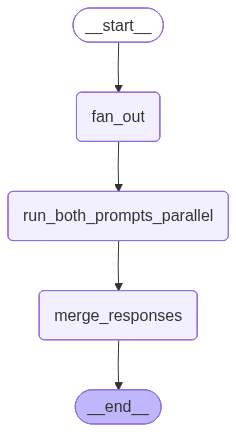

In [7]:
# ── Graph Construction ─────────────────────────────────────
def build_dual_graph():
    builder = StateGraph(DualState)

    builder.add_node("fan_out",                  fan_out)
    builder.add_node("run_both_prompts_parallel", run_both_prompts_parallel)
    builder.add_node("merge_responses",           merge_responses)

    builder.add_edge(START,                       "fan_out")
    builder.add_edge("fan_out",                   "run_both_prompts_parallel")
    builder.add_edge("run_both_prompts_parallel", "merge_responses")
    builder.add_edge("merge_responses",            END)

    return builder.compile()


graph = build_dual_graph()
display(Image(graph.get_graph().draw_mermaid_png()))

In [8]:
# ── Run — single input, two prompts in parallel ───────────
result = graph.invoke({
    "customer_name": "Anil",
    "crm_platform":  "HubSpot",
    "user_message":  (
        "Our transactional emails are going to spam and bouncing. "
        "At the same time, contacts created in CloudBase are not "
        "syncing to HubSpot and we're seeing duplicates."
    ),
    "email_config":    None,
    "crm_config":      None,
    "email_response":  None,
    "crm_response":    None,
    "combined_report": None,
})

[fan_out] Loading both prompt JSON files...
  Loaded: email_specialist vv1.0.0
  Loaded: crm_specialist   vv1.0.0

[run_both] Firing both LLM calls in parallel...
  Email domain result: severity=high
  CRM domain result:   severity=high

[merge] Combining both responses into unified report...


In [9]:
# ── Print the combined report ─────────────────────────────
report = result["combined_report"]

print("=" * 60)
print(f"CUSTOMER      : {report['customer']}")
print(f"OVERALL SEV   : {report['overall_severity'].upper()}")
print(f"DOMAINS HIT   : {report['domains_affected']}")
print("=" * 60)

print("\nEMAIL DOMAIN (email_prompt.json)")
print("-" * 40)
print(f"Root cause : {report['email']['root_cause']}")
print(f"Fix time   : {report['email']['estimated_fix']}")
print("Steps:")
for s in report['email']['technical_steps']:
    print(f"  - {s}")
print("DNS to check:")
for d in report['email']['dns_checks']:
    print(f"  - {d}")

print("\nCRM DOMAIN (crm_prompt.json)")
print("-" * 40)
print(f"Root cause : {report['crm']['root_cause']}")
print(f"Fix time   : {report['crm']['estimated_fix']}")
print("Steps:")
for s in report['crm']['technical_steps']:
    print(f"  - {s}")
print("API to check:")
for a in report['crm']['api_checks']:
    print(f"  - {a}")

print("\nRECOMMENDED ORDER")
print("-" * 40)
for i, step in enumerate(report['recommended_action_order'], 1):
    print(f"  {i}. {step}")

CUSTOMER      : Anil
OVERALL SEV   : HIGH
DOMAINS HIT   : ['email', 'crm']

EMAIL DOMAIN (email_prompt.json)
----------------------------------------
Root cause : Missing or misconfigured DKIM signature causing spam filter rejection; soft bounces from reputation issues on sending IP. Additionally, API integration issues between CloudBase and HubSpot causing sync failures and duplicates.
Fix time   : 4-6 hours for email issues; additional time for integration troubleshooting
Steps:
  - Check DKIM selector record in DNS: dig TXT default._domainkey.yourdomain.com
  - Verify SPF record includes CloudBase sending IPs
  - Review bounce log for 4xx vs 5xx codes to distinguish soft vs hard bounces
  - Warm up new sending IP gradually if recently changed
  - Verify API keys and permissions for CloudBase and HubSpot integration
  - Check for any existing integration errors or logs in CloudBase and HubSpot
  - Ensure deduplication settings are correctly configured in HubSpot
DNS to check:
  - SPF

In [10]:
# ── Raw JSON output ───────────────────────────────────────
print(json.dumps(result["combined_report"], indent=2))

{
  "customer": "Anil",
  "issue_summary": "Our transactional emails are going to spam and bouncing. At the same time, contacts created in CloudBase are not syncing to HubSpot and we're seeing duplicates.",
  "overall_severity": "high",
  "domains_affected": [
    "email",
    "crm"
  ],
  "email": {
    "prompt_version": "v1.0.0",
    "root_cause": "Missing or misconfigured DKIM signature causing spam filter rejection; soft bounces from reputation issues on sending IP. Additionally, API integration issues between CloudBase and HubSpot causing sync failures and duplicates.",
    "technical_steps": [
      "Check DKIM selector record in DNS: dig TXT default._domainkey.yourdomain.com",
      "Verify SPF record includes CloudBase sending IPs",
      "Review bounce log for 4xx vs 5xx codes to distinguish soft vs hard bounces",
      "Warm up new sending IP gradually if recently changed",
      "Verify API keys and permissions for CloudBase and HubSpot integration",
      "Check for any exi

## How parallel invocation works

The key is in `run_both_prompts_parallel`:

```python
async def run_parallel():
    email_task = call_prompt_async(email_config, email_vars)
    crm_task   = call_prompt_async(crm_config,   crm_vars)
    return await asyncio.gather(email_task, crm_task)  # both fire at once
```

`asyncio.gather()` starts both API calls simultaneously and waits for both to finish.

| Approach | Time taken |
|---|---|
| Sequential (one after the other) | email_time + crm_time ≈ 6s |
| Parallel (both at once) | max(email_time, crm_time) ≈ 3s |

## How to add a third prompt

1. Create `prompts_dual/billing_prompt.json`
2. In `fan_out`, add: `billing_config = load_json("billing_prompt.json")`
3. In `run_both_prompts_parallel`, add a third task to `asyncio.gather()`
4. In `merge_responses`, include the billing result in the report

No graph structure changes needed — just add to the existing parallel node.